--- Part 1: Configuration ---

Part 2: Identifying 'Super-Common' cell lines across all models...


Checking Model Scopes:   0%|          | 0/10 [00:00<?, ?it/s]

   Loading expression index from /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Exp.csv...


Checking Model Scopes: 100%|██████████| 10/10 [01:31<00:00,  9.15s/it]


✅ Found 170 'super-common' cell lines used for comparison.

Part 3: Projecting data, Scaling, and Applying PCA (10 comps)...


Processing Models: 100%|██████████| 10/10 [01:34<00:00,  9.46s/it]
/home/nilabjab/miniconda3/envs/pyenv3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Combined Latent Matrix Shape: (1700, 10)

Part 4: Running UMAP on PCA-reduced data...
   Running UMAP...

Part 5: Plotting...


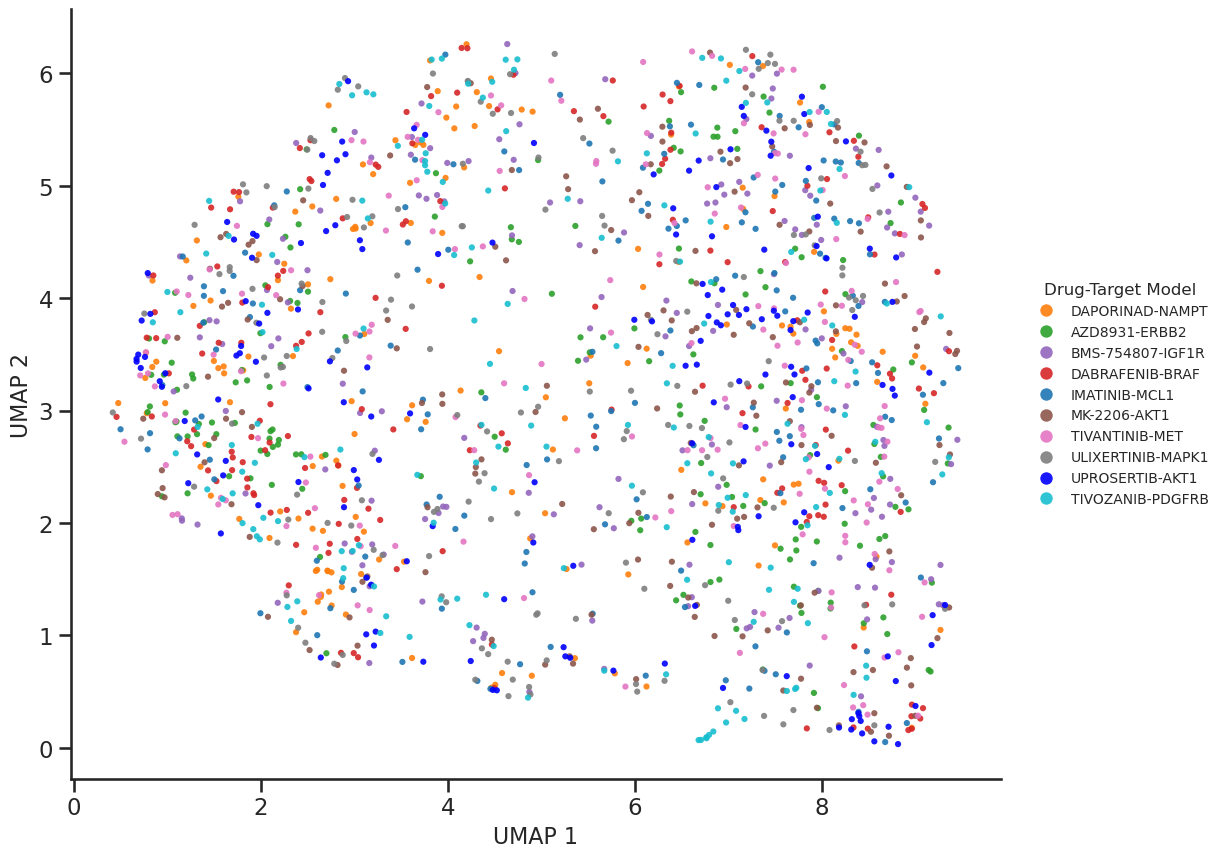


Done.


In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from matplotlib import rcParams
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm
import json
# =============================================================================
# PART 1: CONFIGURATION
# =============================================================================
print("--- Part 1: Configuration ---")
# --- Configure Matplotlib ---
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
sns.set(style="ticks", context="talk", font_scale=1.0)
# --- Define Paths ---
BASE_MODELS_DIR = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models"
# SPECIFIC MODEL FILE FOR DAPORINAD_NAMPT
DAPORINAD_NAMPT_MODEL = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/DAPORINAD_NAMPT_forgeModel_optuna100_321456.pkl"
# Output Directories
BASE_OUTPUT_DIR = "UMAP_Analysis"
DATA_DIR = os.path.join(BASE_OUTPUT_DIR, "Data")
FIGS_DIR = os.path.join(BASE_OUTPUT_DIR, "Figs")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)
# --- List of Specific Drug-Target Pairs ---
specific_pairs = [
    {'drug_name': 'DAPORINAD', 'target': 'NAMPT'}, 
    {'drug_name': 'AZD8931', 'target': 'ERBB2'},
    {'drug_name': 'BMS-754807', 'target': 'IGF1R'}, 
    {'drug_name': 'DABRAFENIB', 'target': 'BRAF'},
    {'drug_name': 'IMATINIB', 'target': 'MCL1'}, 
    {'drug_name': 'MK-2206', 'target': 'AKT1'},
    {'drug_name': 'TIVANTINIB', 'target': 'MET'}, 
    {'drug_name': 'ULIXERTINIB', 'target': 'MAPK1'}, 
    {'drug_name': 'UPROSERTIB', 'target': 'AKT1'}, 
    {'drug_name': 'TIVOZANIB', 'target': 'PDGFRB'}
]
# =============================================================================
# PART 2: FIND THE "SUPER-COMMON" SET OF CELL LINES
# =============================================================================
print("\n" + "="*80)
print("Part 2: Identifying 'Super-Common' cell lines across all models...")
sets_of_valid_cells = []
cached_exp_paths = {}
def load_model(drug, target):
    # Check if this is the DAPORINAD_NAMPT pair - use special model file
    if drug == 'DAPORINAD' and target == 'NAMPT':
        fpath = DAPORINAD_NAMPT_MODEL
    else:
        fname = f"{drug}_{target}_forgeModel_optuna100.pkl"
        fpath = os.path.join(BASE_MODELS_DIR, fname)
    
    if not os.path.exists(fpath):
        return None
    with open(fpath, "rb") as f:
        return pickle.load(f)
# 1. First pass: Collect cell line sets
global_exp_index = None
for pair in tqdm(specific_pairs, desc="Checking Model Scopes"):
    drug = pair['drug_name']
    target = pair['target']
    
    model = load_model(drug, target)
    if model is None:
        print(f"Skipping {drug}: Model file not found.")
        continue
        
    # If this is the first time, load the expression index
    if global_exp_index is None:
        print(f"   Loading expression index from {model.exp_path}...")
        temp_df = pd.read_csv(model.exp_path, index_col=0, usecols=[0]) 
        global_exp_index = set(temp_df.index)
    # Union of Train and Test lines for this model
    model_cells = set(model.train_cellLines) | set(model.test_cellLines)
    
    # Intersection with available expression data
    valid_cells = model_cells & global_exp_index
    sets_of_valid_cells.append(valid_cells)
if not sets_of_valid_cells:
    print("CRITICAL ERROR: No valid models found.")
    exit()
# Find intersection across ALL models
super_common_set = set.intersection(*sets_of_valid_cells)
super_common_cell_lines = sorted(list(super_common_set))
if len(super_common_cell_lines) < 20:
    print(f"\nCRITICAL ERROR: Only found {len(super_common_cell_lines)} common cell lines.")
    exit()
print(f"✅ Found {len(super_common_cell_lines)} 'super-common' cell lines used for comparison.")
# Save common cell lines
with open(os.path.join(DATA_DIR, "common_cell_lines_across_drugs.pkl"), "wb") as f:
    pickle.dump(super_common_cell_lines, f)
# =============================================================================
# PART 3: GENERATE LATENT VECTORS & APPLY INDEPENDENT PCA
# =============================================================================
print("\n" + "="*80)
print("Part 3: Projecting data, Scaling, and Applying PCA (10 comps)...")
all_latent_vectors_pca = []
all_labels = []
cached_exp_df = None
current_exp_path = None
TARGET_PCA_COMPONENTS = 10
for pair in tqdm(specific_pairs, desc="Processing Models"):
    drug = pair['drug_name']
    target = pair['target']
    pair_label = f"{drug}-{target}"
    
    model = load_model(drug, target)
    if model is None: continue
    # 1. Load Expression (Cached)
    if model.exp_path != current_exp_path:
        full_exp_df = pd.read_csv(model.exp_path, index_col=0)
        full_exp_df = full_exp_df[~full_exp_df.index.duplicated(keep='first')]
        cached_exp_df = full_exp_df
        current_exp_path = model.exp_path
    
    # 2. Subset Data
    try:
        E_subset = cached_exp_df.loc[super_common_cell_lines, model.hcg_list]
        G = E_subset.to_numpy()
    except KeyError as e:
        print(f"   Error: Missing genes/cells for {drug}. {e}")
        continue
        
    # 3. Calculate Raw Latent Z
    if G.shape[1] != model.W.shape[0]:
        print(f"   Shape mismatch for {drug}. Skipping.")
        continue
        
    Z_raw = G @ model.W
    
    # 4. Standard Scale per model
    scaler = StandardScaler()
    Z_scaled = scaler.fit_transform(Z_raw)
    # 5. Apply PCA to reduce/standardize to 10 components
    if Z_scaled.shape[1] < TARGET_PCA_COMPONENTS:
        print(f"   ⚠️ WARNING: {drug} has only {Z_scaled.shape[1]} latent factors. Padding to {TARGET_PCA_COMPONENTS}.")
        pca = PCA(n_components=Z_scaled.shape[1])
        Z_reduced = pca.fit_transform(Z_scaled)
        pad_width = TARGET_PCA_COMPONENTS - Z_scaled.shape[1]
        Z_final = np.pad(Z_reduced, ((0,0), (0, pad_width)), mode='constant')
    else:
        pca = PCA(n_components=TARGET_PCA_COMPONENTS)
        Z_final = pca.fit_transform(Z_scaled)
    
    # Store
    all_latent_vectors_pca.append(Z_final)
    all_labels.extend([pair_label] * len(super_common_cell_lines))
if not all_latent_vectors_pca:
    print("No latent vectors generated.")
    exit()
# 6. Stack
combined_Z = np.vstack(all_latent_vectors_pca)
print(f"✅ Combined Latent Matrix Shape: {combined_Z.shape}") 
# =============================================================================
# PART 4: UMAP ON PCA-REDUCED DATA
# =============================================================================
print("\n" + "="*80)
print("Part 4: Running UMAP on PCA-reduced data...")
print("   Running UMAP...")
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='cosine'
)
embedding = reducer.fit_transform(combined_Z)
umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
# =============================================================================
# PART 5: VISUALIZATION
# =============================================================================
print("\n" + "="*80)
print("Part 5: Plotting...")
plot_df = umap_df.copy()
plot_df['Model'] = all_labels
unique_labels = plot_df['Model'].unique()
custom_colors = [
    "#ff7e0d", "#2ba02b", "#9466bc", "#d62627", 
    "#1e76b3", "#8c554b", "#e375c2", "#7e7e7e", 
    "#0000ff", "#17becf"
]
import itertools
palette = dict(zip(unique_labels, itertools.cycle(custom_colors)))
fig, ax = plt.subplots(figsize=(12, 10))
scatter = sns.scatterplot(
    data=plot_df,
    x='UMAP1',
    y='UMAP2',
    hue='Model',
    palette=palette,
    s=20,
    alpha=0.9,
    edgecolor='none',
    ax=ax
)
for coll in ax.collections:
    coll.set_rasterized(True)
ax.set_xlabel('UMAP 1', fontsize=16)
ax.set_ylabel('UMAP 2', fontsize=16)
sns.despine(top=True, right=True)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title="Drug-Target Model",
    title_fontsize=12,
    fontsize=10,
    markerscale=2,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
#plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig5/Comparative_UMAP.pdf", dpi=600, bbox_inches='tight')
plt.show()
print("\nDone.")